# Setup and Data Acquisition
We will start by installing MLflow for experiment tracking and then download the C-MAPSS dataset from the NASA repository.

In [ ]:
!pip install mlflow xgboost pandas numpy scikit-learn matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 578.1 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install opendatasets -q

In [ ]:
import zipfile
import os
import shutil

local_zip = '/content/archive.zip'
extract_dir = 'cmapss_data'

if os.path.exists(local_zip):
    if not os.path.exists(extract_dir):
        os.makedirs(extract_dir)

    print(f'Extracting {local_zip}...')
    with zipfile.ZipFile(local_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    # Check for nested folders (Kaggle zips often nest files inside one folder)
    extracted_items = os.listdir(extract_dir)
    if len(extracted_items) == 1 and os.path.isdir(os.path.join(extract_dir, extracted_items[0])):
        nested_folder = os.path.join(extract_dir, extracted_items[0])
        for file in os.listdir(nested_folder):
            shutil.move(os.path.join(nested_folder, file), os.path.join(extract_dir, file))
        os.rmdir(nested_folder)

    print('Dataset extracted successfully to cmapss_data/')
    print('Files:', os.listdir(extract_dir))
else:
    print(f'Error: {local_zip} not found. Please ensure the file is uploaded.')

Extracting /content/archive.zip...
Dataset extracted successfully to cmapss_data/
Files: ['train_FD002.txt', 'test_FD004.txt', 'test_FD001.txt', 'train_FD001.txt', 'Damage Propagation Modeling.pdf', 'RUL_FD004.txt', 'RUL_FD001.txt', 'RUL_FD002.txt', 'train_FD004.txt', 'train_FD003.txt', 'test_FD003.txt', 'RUL_FD003.txt', 'test_FD002.txt', 'readme.txt']


In [ ]:
import pandas as pd
import numpy as np
import os
import requests
import zipfile

# Using a reliable mirror for direct download to avoid landing page issues
url = 'https://github.com/nchlis/C-MAPSS-Data/raw/master/CMAPSSData.zip'
zip_path = 'CMAPSSData.zip'

print('Downloading dataset...')
# Use verify=False if there are SSL issues, though GitHub usually works fine
response = requests.get(url, stream=True)
if response.status_code == 200:
    with open(zip_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

try:
    if not os.path.exists('cmapss_data'):
        os.makedirs('cmapss_data')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('cmapss_data')
    print('Dataset extracted successfully.')
    print('Files found:', os.listdir('cmapss_data'))
except Exception as e:
    print(f'Error: {e}')

Error: File is not a zip file


In [ ]:
# Define column names for the dataset
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# Load FD001 training data
try:
    base_path = 'cmapss_data/'
    train_df = pd.read_csv(os.path.join(base_path, 'train_FD001.txt'), sep=r'\s+', header=None, names=col_names)
    test_df = pd.read_csv(os.path.join(base_path, 'test_FD001.txt'), sep=r'\s+', header=None, names=col_names)
    y_test = pd.read_csv(os.path.join(base_path, 'RUL_FD001.txt'), sep=r'\s+', header=None, names=['RUL'])
    print('Data loaded successfully. Shapes:', train_df.shape, test_df.shape)
    display(train_df.head())
except Exception as e:
    print(f'Error loading data: {e}')

Data loaded successfully. Shapes: (20631, 26) (13096, 26)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


# Phase 1: Target Definition and Leakage-Safe Splitting
In this step, we calculate the Ground Truth RUL and the classification target. We also split the data at the engine level (`unit_nr`) to ensure no signal from the same engine appears in both the training and validation sets.

In [ ]:
# 1. Calculate RUL and Target
def add_target_columns(df):
    # Calculate Max Cycle for each unit
    max_cycles = df.groupby('unit_nr')['time_cycles'].max().reset_index()
    max_cycles.columns = ['unit_nr', 'max_cycle']
    df = df.merge(max_cycles, on=['unit_nr'], how='left')

    # Calculate RUL
    df['RUL'] = df['max_cycle'] - df['time_cycles']

    # Define Binary Target: 1 if RUL <= 30, else 0
    df['label_bc'] = np.where(df['RUL'] <= 30, 1, 0)
    return df

train_df = add_target_columns(train_df)

# 2. Leakage-Safe Entity-Level Split
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(train_df, groups=train_df['unit_nr']))

# Split engines into train and validation sets
train_data = train_df.iloc[train_idx].copy()
val_data = train_df.iloc[val_idx].copy()

print(f"Training set shape: {train_data.shape} (Units: {train_data['unit_nr'].nunique()})")
print(f"Validation set shape: {val_data.shape} (Units: {val_data['unit_nr'].nunique()})")
display(train_data[['unit_nr', 'time_cycles', 'RUL', 'label_bc']].head())

Training set shape: (16561, 29) (Units: 80)
Validation set shape: (4070, 29) (Units: 20)


,unit_nr,time_cycles,RUL,label_bc
192,2,1,286,0
193,2,2,285,0
194,2,3,284,0
195,2,4,283,0
196,2,5,282,0


# Phase 1: Time-Aware Feature Engineering Pipeline
We will now build the `CMapssFeaturePipeline`. This custom estimator will:
1. **Prune** constant sensors (s_1, s_5, s_10, s_16, s_18, s_19).
2. **Generate Rolling Statistics** (Mean/Std) for windows $W \in [5, 14, 21]$.
3. **Compute Trends** (Delta from baseline and velocity).
4. **Scale** features using `RobustScaler` fitted only on training data.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler
import joblib
import pandas as pd
import numpy as np

class CMapssFeaturePipeline(BaseEstimator, TransformerMixin):
    def __init__(self, windows=[5, 14, 21]):
        self.windows = windows
        self.drop_sensors = ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']
        self.scaler = RobustScaler()
        self.feature_names = []

    def fit(self, X, y=None):
        X_engineered = self._engineer_features(X)
        self.scaler.fit(X_engineered)
        self.feature_names = X_engineered.columns.tolist()
        return self

    def transform(self, X):
        X_engineered = self._engineer_features(X)
        X_scaled = self.scaler.transform(X_engineered)
        return pd.DataFrame(X_scaled, columns=self.feature_names, index=X.index)

    def _engineer_features(self, X):
        df = X.copy()
        new_cols = {}

        # 1. Pruning
        df = df.drop(columns=self.drop_sensors + ['setting_3'], errors='ignore')
        remaining_sensors = [s for s in sensor_names if s not in self.drop_sensors]

        # 2. Rolling Aggregations
        for w in self.windows:
            for s in remaining_sensors:
                new_cols[f'{s}_roll_mean_{w}'] = df.groupby('unit_nr')[s].transform(lambda x: x.rolling(window=w, min_periods=1).mean())
                new_cols[f'{s}_roll_std_{w}'] = df.groupby('unit_nr')[s].transform(lambda x: x.rolling(window=w, min_periods=1).std()).fillna(0)

        # 3. Sensor Trends & Deltas
        for s in remaining_sensors:
            # Delta from engine initial baseline
            first_val = df.groupby('unit_nr')[s].transform('first')
            new_cols[f'{s}_delta_baseline'] = df[s] - first_val

            # Instantaneous velocity (Current - Prev Mean)
            prev_mean = df.groupby('unit_nr')[s].transform(lambda x: x.rolling(window=5, min_periods=1).mean().shift(1)).bfill()
            new_cols[f'{s}_velocity'] = df[s] - prev_mean

        # Concatenate all new features at once to avoid fragmentation warnings
        df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

        # Drop metadata for scaling/training
        return df.drop(columns=['unit_nr', 'time_cycles'], errors='ignore')

# Instantiate and Process
pipeline = CMapssFeaturePipeline()
X_train = pipeline.fit_transform(train_data.drop(columns=['max_cycle', 'RUL', 'label_bc']))
y_train = train_data['label_bc']

X_val = pipeline.transform(val_data.drop(columns=['max_cycle', 'RUL', 'label_bc']))
y_val = val_data['label_bc']

print(f"Engineered Training Features: {X_train.shape}")
joblib.dump(pipeline, 'cmapss_pipeline.joblib')
print("Pipeline artifact exported as cmapss_pipeline.joblib")
X_train.head()

Engineered Training Features: (16561, 137)
Pipeline artifact exported as cmapss_pipeline.joblib


,setting_1,setting_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,...,s_14_delta_baseline,s_14_velocity,s_15_delta_baseline,s_15_velocity,s_17_delta_baseline,s_17_velocity,s_20_delta_baseline,s_20_velocity,s_21_delta_baseline,s_21_velocity
192,-0.600000,1.2,-1.136364,-0.772105,-1.380399,-0.01,0.915254,-0.888889,-0.380923,-1.657143,...,-0.170018,-0.073091,-0.368737,-0.042895,-0.5,0.000000,0.384615,0.040000,0.463087,0.040730
193,1.433333,-0.6,-1.242424,-0.372354,-1.226744,0.00,1.118644,-1.222222,-0.590769,-0.771429,...,-0.776051,-1.426705,0.156313,0.835121,0.0,0.714286,0.846154,0.840000,0.127517,-0.515691
194,0.600000,0.6,-1.651515,-0.214197,-0.742525,-0.01,1.432203,-0.555556,-0.410462,-0.828571,...,0.091408,1.187628,-0.575150,-0.827078,-0.5,-0.357143,1.038462,0.773333,0.238255,-0.053862
195,1.166667,-0.8,-1.454545,-0.733499,-0.981728,0.00,0.677966,-1.222222,-0.178462,-1.171429,...,0.078611,0.738805,-0.142285,0.158177,-0.5,-0.238095,1.115385,0.662222,0.759732,0.842347
196,0.166667,0.8,-1.378788,-1.371108,-0.446844,-0.01,1.415254,-0.666667,-0.169846,-0.742857,...,-0.265996,-0.233871,-0.444890,-0.398123,-1.0,-0.892857,1.307692,0.840000,0.227517,-0.240541


# Phase 2: Modeling & Experiment Tracking
We will evaluate two models:
1. **Baseline**: Logistic Regression (L2 regularized).
2. **Challenger**: XGBoost Classifier.

We will use MLflow to log parameters, metrics, and models.

In [ ]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score
import joblib

# Initialize MLflow experiment
mlflow.set_experiment("CMAPSS_Predictive_Maintenance")

# Calculate class ratio for imbalanced weighting
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def evaluate_and_log_model(model, X_tr, y_tr, X_v, y_v, run_name, model_type="sklearn"):
    with mlflow.start_run(run_name=run_name):
        model.fit(X_tr, y_tr)
        y_pred_proba = model.predict_proba(X_v)[:, 1]
        y_pred = (y_pred_proba > 0.5).astype(int)

        # Metrics
        metrics = {
            "auc": roc_auc_score(y_v, y_pred_proba),
            "f1": f1_score(y_v, y_pred),
            "precision": precision_score(y_v, y_pred),
            "recall": recall_score(y_v, y_pred)
        }

        mlflow.log_params(model.get_params() if hasattr(model, 'get_params') else {})
        mlflow.log_metrics(metrics)
        mlflow.log_artifact('cmapss_pipeline.joblib')

        if model_type == "xgboost":
            mlflow.xgboost.log_model(model, "model", registered_model_name=f"CMAPSS_{run_name}")
        else:
            mlflow.sklearn.log_model(model, "model", registered_model_name=f"CMAPSS_{run_name}")

        print(f"--- {run_name} Results ---")
        for k, v in metrics.items(): print(f"{k.upper()}: {v:.4f}")
        return model, y_pred_proba

# 1. Baseline: Logistic Regression with balanced weights
lr_model, y_proba_lr = evaluate_and_log_model(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    X_train, y_train, X_val, y_val, "LR_Baseline", "sklearn"
)

# 2. Challenger: XGBoost with scale_pos_weight
xgb_model, y_proba_xgb = evaluate_and_log_model(
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, scale_pos_weight=pos_weight, random_state=42, eval_metric='logloss'),
    X_train, y_train, X_val, y_val, "XGBoost_Challenger", "xgboost"
)

2026/08/11 22:18:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'CMAPSS_LR_Baseline'.
Created version '1' of model 'CMAPSS_LR_Baseline'.


--- LR_Baseline Results ---
AUC: 0.9954
F1: 0.9124
PRECISION: 0.8710
RECALL: 0.9581


2026/08/11 22:18:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- XGBoost_Challenger Results ---
AUC: 0.9962
F1: 0.9185
PRECISION: 0.8933
RECALL: 0.9452


Successfully registered model 'CMAPSS_XGBoost_Challenger'.
Created version '1' of model 'CMAPSS_XGBoost_Challenger'.


### Model Performance Comparison
We will visualize the ROC and Precision-Recall curves to compare the Logistic Regression baseline against the XGBoost challenger.

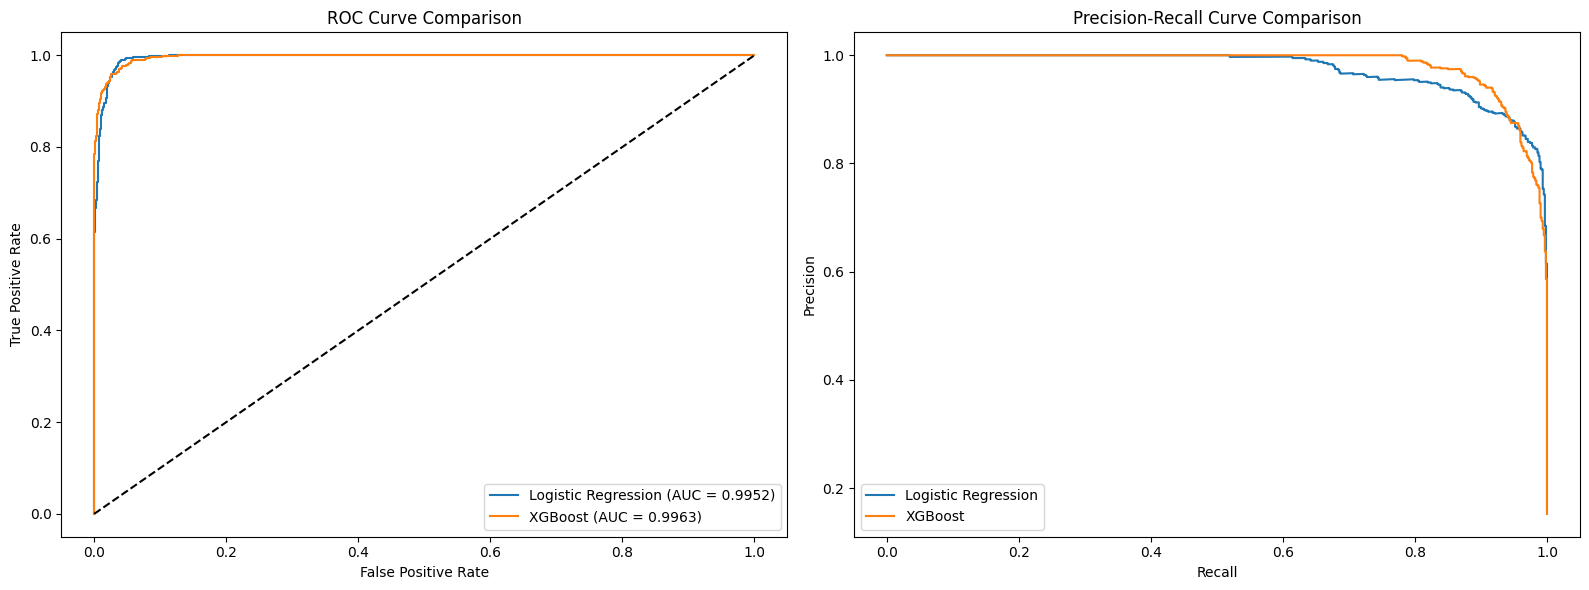

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_proba_xgb)

ax[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_val, y_proba_lr):.4f})')
ax[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_val, y_proba_xgb):.4f})')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('ROC Curve Comparison')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()

# Precision-Recall Curve
pre_lr, rec_lr, _ = precision_recall_curve(y_val, y_proba_lr)
pre_xgb, rec_xgb, _ = precision_recall_curve(y_val, y_proba_xgb)

ax[1].plot(rec_lr, pre_lr, label='Logistic Regression')
ax[1].plot(rec_xgb, pre_xgb, label='XGBoost')
ax[1].set_title('Precision-Recall Curve Comparison')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.tight_layout()
plt.show()

### Phase 3: Model Export and Test Inference
We will save the final XGBoost model and demonstrate how to use the full pipeline (Preprocessing + Inference) on the unseen test data.

In [ ]:
print("--- Running Corrected Test Set Inference ---")
# 1. Transform FULL test sequence to preserve rolling history
X_test_full = pipeline.transform(test_df)

# 2. Re-attach unit_nr to identify the last cycle
X_test_full['unit_nr'] = test_df['unit_nr'].values

# 3. Extract the last cycle for each engine to predict current status
test_latest_features = X_test_full.groupby('unit_nr').tail(1).drop(columns=['unit_nr'])

# 4. Predict
test_probs = xgb_model.predict_proba(test_latest_features)[:, 1]
test_preds = (test_probs > 0.5).astype(int)

# 5. Evaluate against RUL Ground Truth (y_test <= 30)
# Using y_test which was defined in the loading step
y_test_binary = (y_test['RUL'] <= 30).astype(int)

test_results = pd.DataFrame({
    'unit_nr': range(1, 101),
    'failure_probability': test_probs,
    'prediction': test_preds,
    'ground_truth': y_test_binary.values
})

from sklearn.metrics import f1_score, roc_auc_score
print(f"Test Set F1-Score: {f1_score(y_test_binary, test_preds):.4f}")
print(f"Test Set AUC: {roc_auc_score(y_test_binary, test_probs):.4f}")
display(test_results.head(10))

--- Running Corrected Test Set Inference ---
Test Set F1-Score: 0.9020
Test Set AUC: 0.9893


,unit_nr,failure_probability,prediction,ground_truth
0,1,0.003172,0,0
1,2,0.003172,0,0
2,3,0.044523,0,0
3,4,0.004388,0,0
4,5,0.008419,0,0
5,6,0.003172,0,0
6,7,0.004195,0,0
7,8,0.009533,0,0
8,9,0.003333,0,0
9,10,0.003172,0,0
